In [2]:
!pip install selenium webdriver-manager pandas matplotlib seaborn

In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [4]:
options = Options()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

In [5]:
url = "https://www.naukri.com/data-analyst-jobs"
driver.get(url)
time.sleep(5)

print(driver.title)

30642 Data Analyst Jobs Vacancies - Naukri.com


In [6]:
job_titles = []
companies = []
locations = []
experiences = []
skills_list = []

target_jobs = 100

page = 1

while len(job_titles) < target_jobs:

    print(f"\nScraping Page {page}")

    url = f"https://www.naukri.com/data-analyst-jobs-{page}"

    driver.get(url)

    time.sleep(5)

    jobs = driver.find_elements(
        By.CLASS_NAME,
        "srp-jobtuple-wrapper"
    )

    print("Jobs Found On Page:", len(jobs))

    for job in jobs:

        # STOP if 100 reached
        if len(job_titles) >= target_jobs:
            break

        # JOB TITLE
        try:
            title = job.find_element(
                By.CLASS_NAME,
                "title"
            ).text
        except:
            title = "Not Available"

        # COMPANY
        try:
            company = job.find_element(
                By.CLASS_NAME,
                "comp-name"
            ).text
        except:
            company = "Not Available"

        # LOCATION
        try:
            location = job.find_element(
                By.CLASS_NAME,
                "locWdth"
            ).text
        except:
            location = "Not Available"

        # EXPERIENCE
        try:
            experience = job.find_element(
                By.CLASS_NAME,
                "expwdth"
            ).text
        except:
            experience = "Not Available"

        # SKILLS
        try:
            skills = job.find_element(
                By.CLASS_NAME,
                "tags-gt"
            ).text
        except:
            skills = "Not Available"

        # STORE DATA
        job_titles.append(title)
        companies.append(company)
        locations.append(location)
        experiences.append(experience)
        skills_list.append(skills)

    print("Total Collected:", len(job_titles))

    # GO TO NEXT PAGE
    page += 1

# CREATE DATAFRAME
df = pd.DataFrame({
    "Job Title": job_titles,
    "Company": companies,
    "Location": locations,
    "Experience": experiences,
    "Skills": skills_list
})

print(df.head())

print("\nFinal Dataset Size:", len(df))


Scraping Page 1
Jobs Found On Page: 20
Total Collected: 20

Scraping Page 2
Jobs Found On Page: 20
Total Collected: 40

Scraping Page 3
Jobs Found On Page: 20
Total Collected: 60

Scraping Page 4
Jobs Found On Page: 20
Total Collected: 80

Scraping Page 5
Jobs Found On Page: 20
Total Collected: 100
                         Job Title                         Company  \
0                     Data Analyst                        Acciojob   
1    Online Data Analyst Odia (IN)                   TELUS Digital   
2              Splunk Data Analyst                          Apptad   
3                     Data Analyst  Lloyds Technology Centre India   
4  Data Analyst (English Required)                        Peroptyx   

                                       Location Experience  \
0                        Noida, Hyderabad, Pune    0-2 Yrs   
1                                        Remote    0-5 Yrs   
2  Hubli, Mangaluru, Mysuru, Bengaluru, Belgaum    0-3 Yrs   
3                             

In [13]:
df.to_csv("naukri_data_analyst_jobs.csv", index=False)

print("CSV Saved Successfully")

driver.quit()

CSV Saved Successfully


In [8]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Job Title   100 non-null    object
 1   Company     100 non-null    object
 2   Location    100 non-null    object
 3   Experience  100 non-null    object
 4   Skills      100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB
None
           Job Title        Company   Location Experience  \
count            100            100        100        100   
unique            34             74         41         38   
top     Data Analyst  TELUS Digital  Hyderabad    0-2 Yrs   
freq              62              6         12         10   

                                                   Skills  
count                                                 100  
unique                                                 84  
top     Change managementData managementManagement sys...  
freq                      

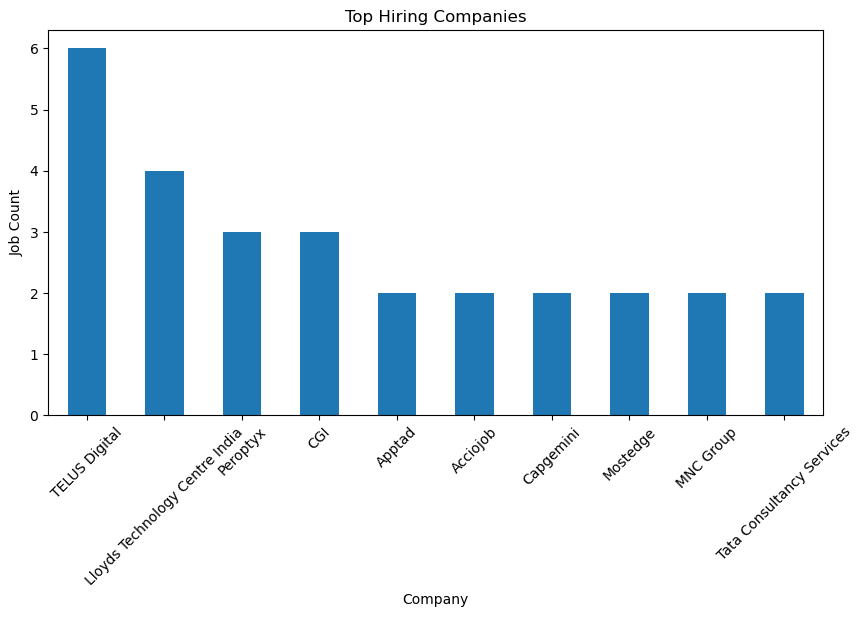

In [9]:
top_companies = df["Company"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_companies.plot(kind="bar")

plt.title("Top Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Job Count")

plt.xticks(rotation=45)

plt.show()

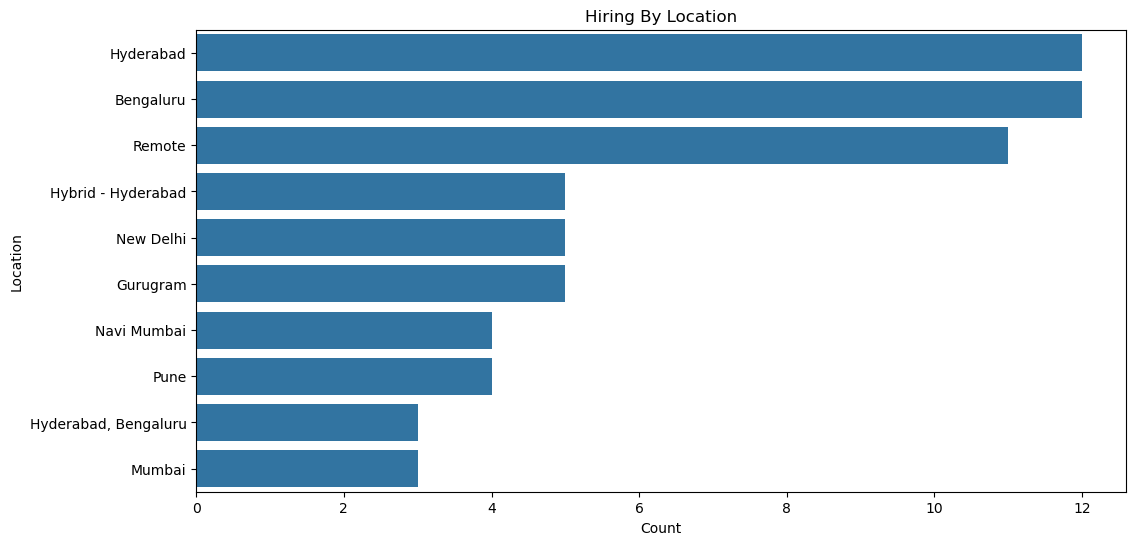

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df["Location"],
    order=df["Location"].value_counts().head(10).index
)

plt.title("Hiring By Location")
plt.xlabel("Count")
plt.ylabel("Location")

plt.show()

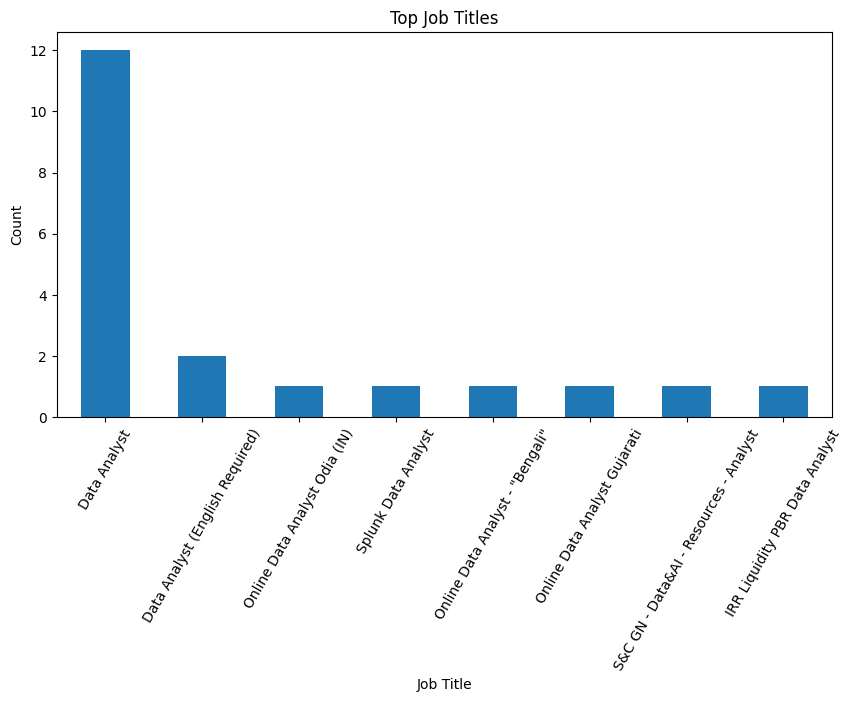

In [14]:
plt.figure(figsize=(10,5))

(df["Job Title"]
 .value_counts()
 .head(10)
 .plot(kind="bar"))

plt.title("Top Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

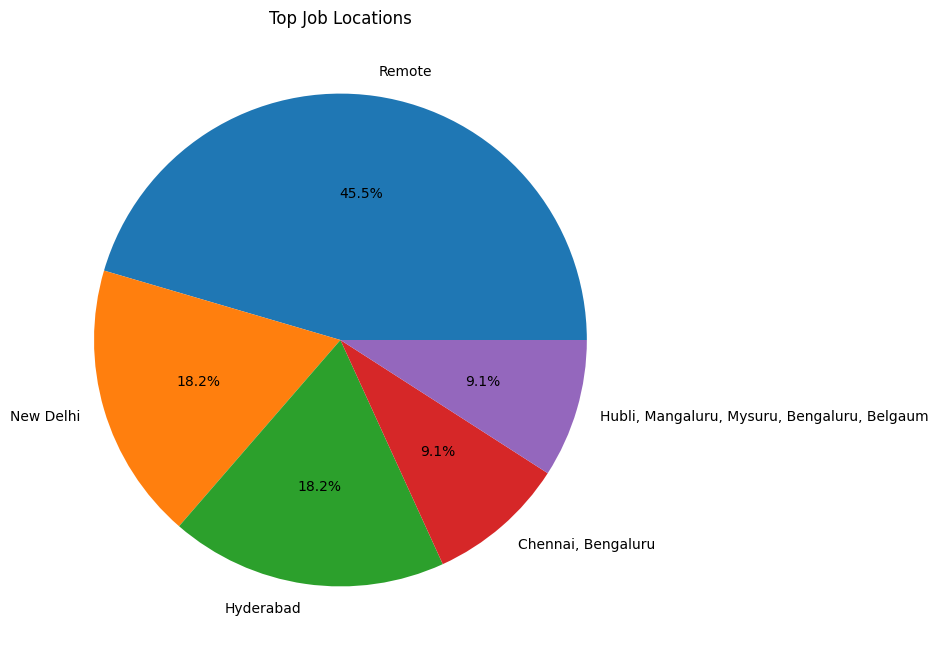

In [15]:
plt.figure(figsize=(8,8))

(df["Location"]
 .value_counts()
 .head(5)
 .plot(kind="pie", autopct="%1.1f%%"))

plt.title("Top Job Locations")

plt.ylabel("")

plt.show()

In [14]:
skills_to_check = [
    "Python",
    "SQL",
    "Machine Learning",
    "Power BI",
    "Excel",
    "Tableau"
]

for skill in skills_to_check:
    df[skill] = df["Skills"].str.contains(
        skill,
        case=False,
        na=False
    )

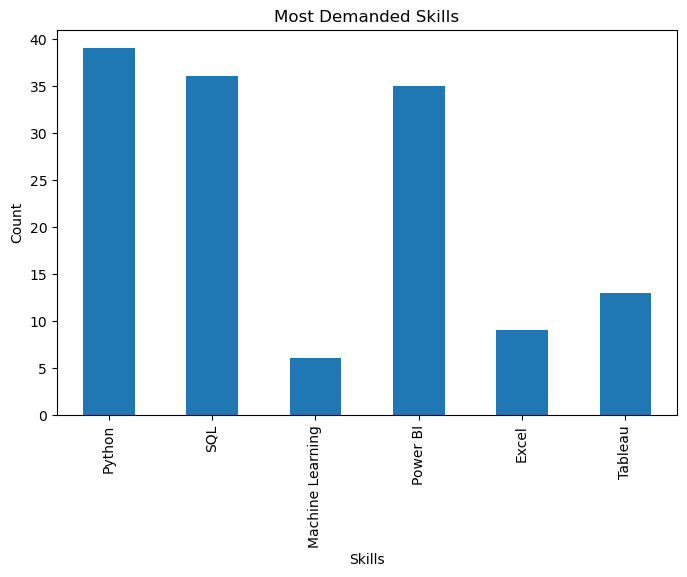

In [15]:
skill_counts = {
    skill: df[skill].sum()
    for skill in skills_to_check
}

skill_df = pd.Series(skill_counts)

plt.figure(figsize=(8,5))

skill_df.plot(kind="bar")

plt.title("Most Demanded Skills")
plt.xlabel("Skills")
plt.ylabel("Count")

plt.show()

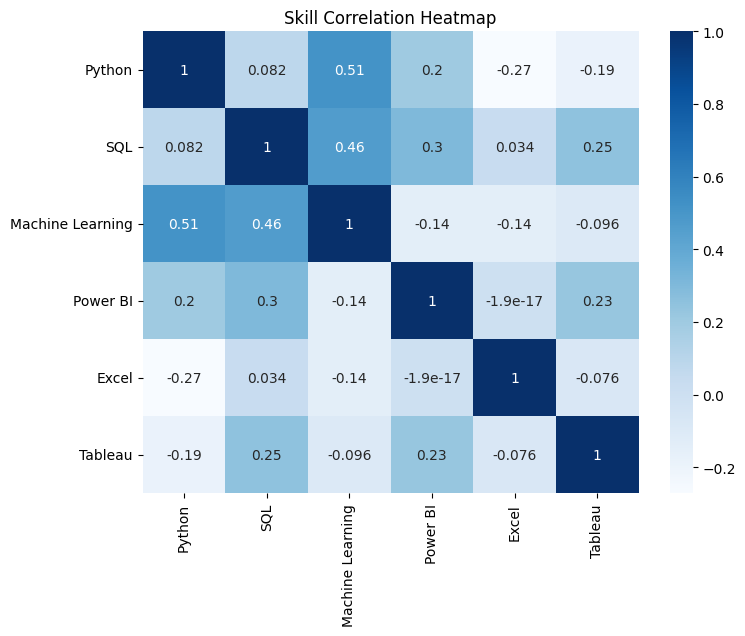

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[skills_to_check].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Skill Correlation Heatmap")

plt.show()

In [17]:
!pip install wordcloud

In [18]:
from wordcloud import WordCloud

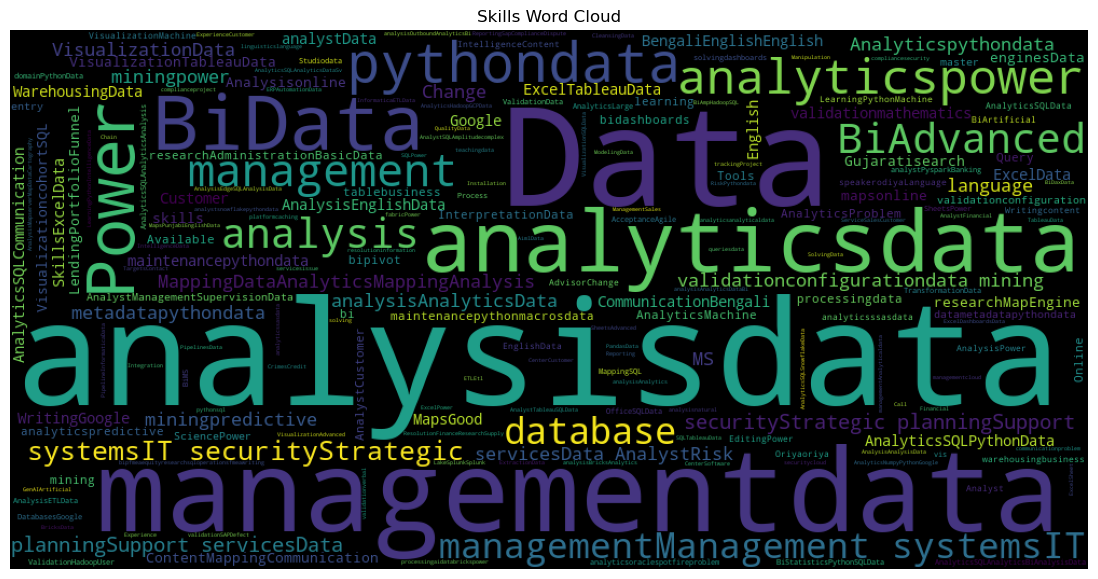

In [20]:


text = " ".join(df["Skills"].dropna())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="black"
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Skills Word Cloud")

plt.show()